# **PROJECT AKHIR PENGANTAR DATA SAINS (PDS)**


### Disusun Oleh:

#### Siti Fadilah Nurkhotimah (NIM 1314623019)
#### Statistika 2023 B



---



Mata Kuliah Pengantar Data Sains

Dosen Pengampu:
- Endang Yuliani, S.Mat., M.Si.
- Faroh Ladayya, M.Si


---











*Judul:*

**ANALISIS KOMPARATIF LOGISTIC REGRESSION DAN DECISION TREE UNTUK MEMPREDIKSI KESELAMATAN PENUMPANG KAPAL RMS (ROYAL MAIL SHIP) TITANIC**

# **Pengambilan Data**

## Import Library

In [513]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_curve, auc

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

## data_titanic

> Membaca Dataset Titanic (Data Latih / *Train*)

In [514]:
data_titanic = pd.read_excel("data_titanic.xlsx")

In [515]:
data_titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [516]:
data_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## data_prediksi

> Membaca Dataset Prediksi (Data Uji / *Test*)

In [517]:
data_prediksi = pd.read_excel("data_prediksi.xlsx")

In [518]:
data_prediksi

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [519]:
data_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


# **Analisis Data Eskploratif (EDA)**

## Bar Chart Jumlah Penumpang berdasarkan Jenis Kelamin

In [520]:
count_sex = data_titanic['Sex'].value_counts()

index_set = count_sex.index
values_sex = count_sex.values

In [521]:
values_sex

array([577, 314])

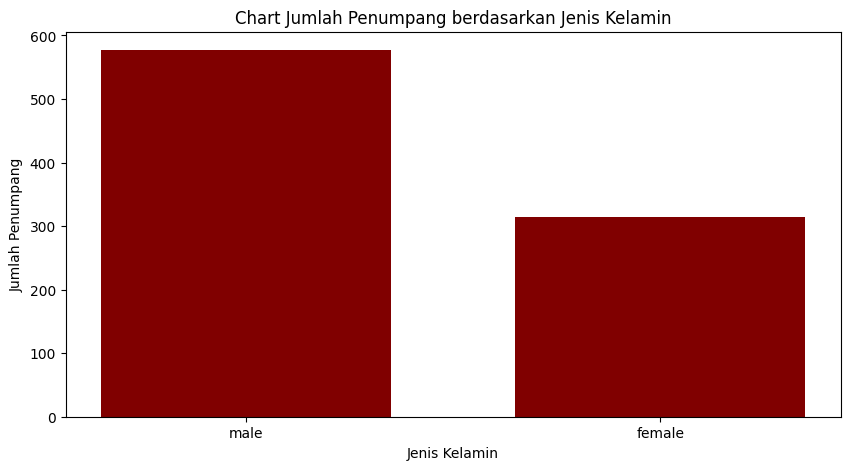

In [522]:
fig = plt.figure(figsize = (10, 5))
plt.bar(index_set , values_sex, color = "maroon", width = 0.7)

plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Penumpang")
plt.title("Chart Jumlah Penumpang berdasarkan Jenis Kelamin")

plt.show()

## Bar Chart Keselamatan Berdasarkan Jenis Kelamin

In [523]:
# count() menghitung berapa banyak baris ID yang termasuk
survived_grp = data_titanic.groupby(['Survived', "Sex"]).count()['PassengerId'].reset_index()
survived_grp

,Survived,Sex,PassengerId
0,0,female,81
1,0,male,468
2,1,female,233
3,1,male,109


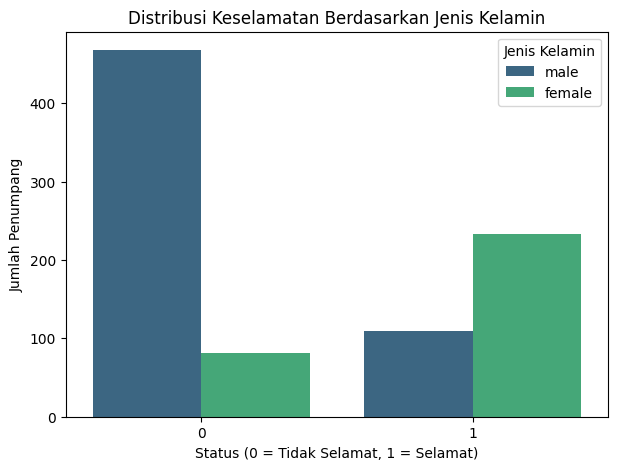

In [524]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data_titanic, x='Survived', hue='Sex', palette='viridis')

plt.title('Distribusi Keselamatan Berdasarkan Jenis Kelamin')
plt.xlabel('Status (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Jenis Kelamin')
plt.show()

> Probabilitas Keselamatan Berdasarkan Jenis Kelamin

/tmp/ipython-input-3156943375.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Sex', y='Survived', data=data_titanic, palette='coolwarm')


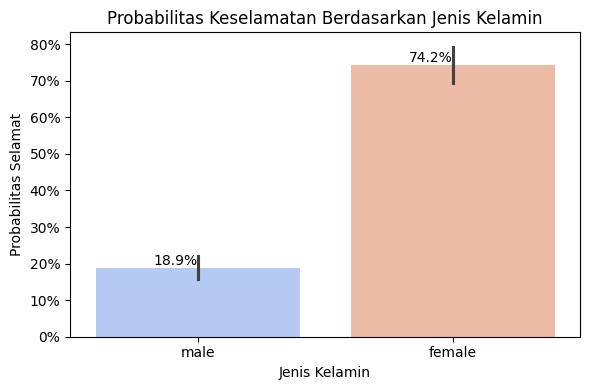

In [525]:
plt.figure(figsize=(6,4))

ax = sns.barplot(x='Sex', y='Survived', data=data_titanic, palette='coolwarm')

# format persen di sumbu y
ax.yaxis.set_major_formatter(lambda y, _: f'{y*100:.0f}%')

# label persentase
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f'{value*100:.1f}%',
        (p.get_x() + p.get_width() / 2, value),
        ha='right',
        va='bottom'
    )
plt.title('Probabilitas Keselamatan Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Probabilitas Selamat')

plt.tight_layout()
plt.show()

## Bar Chart Keselamatan Berdasarkan Kelas Penumpang (Pclass)

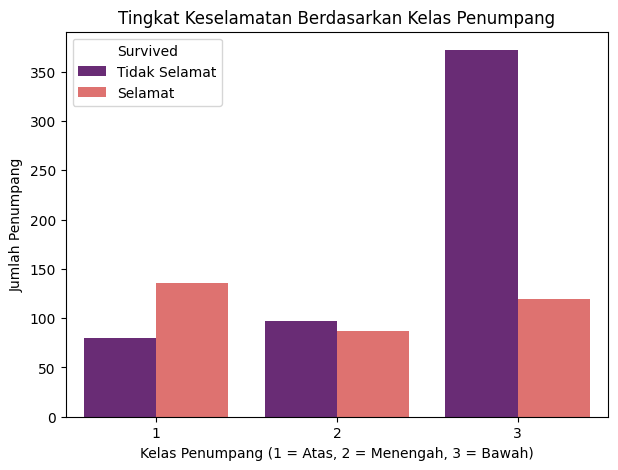

In [526]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data_titanic, x='Pclass', hue='Survived', palette='magma')

plt.title('Tingkat Keselamatan Berdasarkan Kelas Penumpang')
plt.xlabel('Kelas Penumpang (1 = Atas, 2 = Menengah, 3 = Bawah)')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Survived', labels=['Tidak Selamat', 'Selamat'])
plt.show()

## Histogram Distribusi Umur Penumpang

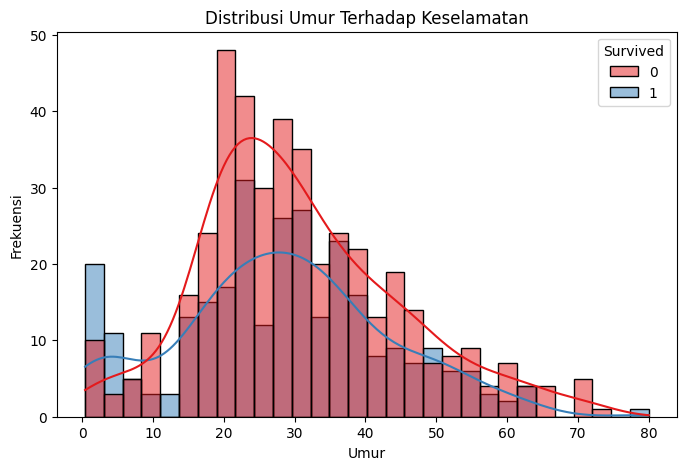

In [527]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data_titanic, x='Age', hue='Survived', kde=True, bins=30, palette='Set1')

plt.title('Distribusi Umur Terhadap Keselamatan')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

## Point Plot Variabel Pelabuhan Keberangkatan, Jenis Kelamin, dan Keselamatan (Multivariate)

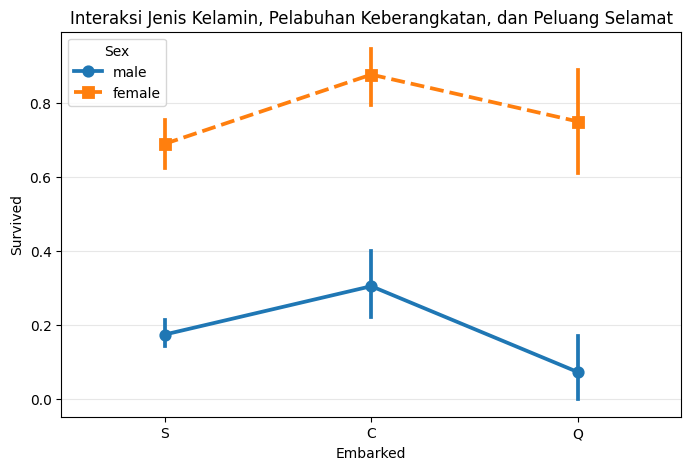

In [528]:
# Interaksi antara Pelabuhan Keberangkatan, Jenis Kelamin, dan Keselamatan
plt.figure(figsize=(8, 5))
sns.pointplot(x='Embarked', y='Survived', hue='Sex', data=data_titanic, markers=['o', 's'], linestyles=['-', '--'])
plt.title('Interaksi Jenis Kelamin, Pelabuhan Keberangkatan, dan Peluang Selamat')
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Pre-processing Data**

## Cek Missing Value

### data_titanic

In [529]:
data_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [530]:
data_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [531]:
missing_percent = (
    data_titanic.isnull().sum() / len(data_titanic) * 100
)

missing_percent

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Penanganan nilai hilang (*missing values*) dengan kriteria standar data sains:

- Jika data hilang < 5%, kita bisa hapus barisnya.

- Jika data hilang 5% - 30%, kita lakukan imputasi (isi dengan nilai rata-rata/median).

- Jika data hilang > 50%, fitur tersebut sebaiknya didrop (dihapus) karena memaksa mengisi data yang mayoritas hilang justru akan memberikan informasi palsu/bias kepada model.

Dalam penelitian ini,

- fitur Age (sekitar 19,8% missing value) dilakukan imputasi median karena bertipe numerik.

- fitur Embarked (sekitar 0,22% missing value) bisa di drop barisnya, tetapi dalam penelitian ini saya akan melakukan imputasi modus karena bertipe kategorik.

- fitur Cabin didrop karena memiliki missing value > 50%, yaitu sekitar 77,1%. Jika Cabin tetap dipertahankan, maka imputasi akan didominasi tebakan, sehingga dapat menimbulkan bias atau pola palsu yang mengurangi validitas dan akurasi prediksi dan model.

### data_prediksi

In [532]:
data_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [533]:
data_prediksi.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [534]:
missing_percent = (
    data_prediksi.isnull().sum() / len(data_titanic) * 100
)

missing_percent

,0
PassengerId,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,9.652076
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.112233
Cabin,36.700337


Penanganan nilai hilang (*missing values*) dengan kriteria standar data sains:

- Jika data hilang < 5%, dilakukan penghapusan barisnya.

- Jika data hilang 5% - 30%, dilakukan imputasi.

- Jika data hilang > 50%, fitur tersebut sebaiknya didrop (dihapus) karena memaksa mengisi data yang mayoritas hilang justru akan memberikan informasi palsu/bias kepada model.

Dalam penelitian ini,

- fitur Age (sekitar 9,6% missing value) dilakukan imputasi median karena bertipe numerik.

- fitur Fare (sekitar 0,11% missing value) dilakukan imputasi median karena bertipe numerik.

- fitur Cabin (sekitar 36,7% missing value), tetapi dalam penelitian ini, menjaga kualitas model dan konsistensi antara data pelatihan dan data pengujian, kolom Cabin harus dihapus dari kedua dataset. Karena jika 77% data pada fitur Cabin di data pelatihan (data_titanic) adalah noise (hasil imputasi), maka model akan mengolah data yang salah dan performa model akan turun.

## Penanganan Missing Value

Imputasi diambil dari data_titanic sebagai data latih agar data_prediksi (data testing) tidak mempengaruhi proses training dan menghindari bias pada evaluasi model.

> Variabel Numerik (Imputasi Median)

Median digunakan agar lebih robust terhadap outlier

In [535]:
# Imputasi dengan Median

data_titanic['Age'].fillna(data_titanic['Age'].median(), inplace=True)
data_prediksi['Age'].fillna(data_titanic['Age'].median(), inplace=True)
data_prediksi['Fare'].fillna(data_titanic['Fare'].median(), inplace=True)

/tmp/ipython-input-344229322.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_titanic['Age'].fillna(data_titanic['Age'].median(), inplace=True)
/tmp/ipython-input-344229322.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

> Variabel Kategorik (Imputasi Modus)

Modus (nilai paling sering muncul)

In [536]:
data_titanic['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [537]:
modus_embarked_train = data_titanic['Embarked'].mode()[0]
modus_embarked_train

'S'

In [538]:
data_prediksi['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


In [539]:
modus_embarked_test = data_prediksi['Embarked'].mode()[0]
modus_embarked_test

'S'

In [540]:
# Imputasi Embarked dengan Modus

data_titanic['Embarked'].fillna(data_titanic['Embarked'].mode()[0], inplace=True)
data_prediksi['Embarked'].fillna(data_titanic['Embarked'].mode()[0], inplace=True)

# indeks [0] untuk mengambil satu nilai modus sebagai isian
# pake modus dari data_titanic sebagai data latih

/tmp/ipython-input-977891176.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_titanic['Embarked'].fillna(data_titanic['Embarked'].mode()[0], inplace=True)
/tmp/ipython-input-977891176.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

> drop fitur Cabin di data_titanic dan data_prediksi

In [541]:
data_titanic.drop(columns=['Cabin'], inplace=True)
data_prediksi.drop(columns=['Cabin'], inplace=True)

### Cek dataset

Cek dataset setelah dilakukan imputasi dan drop kolom fitur

> data_titanic (data latih)

In [542]:
data_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [543]:
data_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


> data_prediksi (data uji)

In [544]:
data_prediksi.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [545]:
data_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


## Transformasi Data (Encoding)

Variabel ber tipe kategorik adalah Sex dan Embarked

> Binary Encoding Data Sex

In [546]:
sex_mapping = {"male" : 1, "female" : 0}

data_titanic['Sex'] = data_titanic['Sex'].map(sex_mapping)
data_prediksi['Sex'] = data_prediksi['Sex'].map(sex_mapping)

> One-Hot Encoding Data Embarked

Kategori: S, C, Q

In [547]:
# OHE Embarked di data_titanic
embarked_train = data_titanic[['Embarked']]
ohe_embarked_train = pd.get_dummies(embarked_train, dtype=int)

ohe_embarked_train.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [548]:
data_titanic = pd.merge(data_titanic.reset_index(), ohe_embarked_train.reset_index())

data_titanic = data_titanic.drop(['index', 'Embarked'], axis = 1)

In [549]:
# OHE Embarked di data_titanic
embarked_test = data_prediksi[['Embarked']]
ohe_embarked_test = pd.get_dummies(embarked_test, dtype=int)

ohe_embarked_test.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0
1,0,0,1
2,0,1,0
3,0,0,1
4,0,0,1


In [550]:
data_prediksi = pd.merge(data_prediksi.reset_index(), ohe_embarked_test.reset_index())

data_prediksi = data_prediksi.drop(['index', 'Embarked'], axis = 1)

## Feature engineering

Fitur Title diekstraksi dari variabel Name

> data_titanic

In [551]:
data_titanic['Title'] = data_titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-858750224.py:1: SyntaxWarning: invalid escape sequence '\.'
  data_titanic['Title'] = data_titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)


In [552]:
data_titanic['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [553]:
title_mapping = {"Mr": 0,
                 "Miss": 1,
                 "Mrs": 2,
                 "Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Major": 3, "Mlle": 3,"Countess": 3, "Ms": 3, "Lady": 3, "Jonkheer": 3, "Don": 3, "Dona" : 3, "Mme": 3,"Capt": 3,"Sir": 3 }

data_titanic['Title'] = data_titanic['Title'].map(title_mapping)

> data_prediksi

In [554]:
data_prediksi['Title'] = data_prediksi['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-3270889320.py:1: SyntaxWarning: invalid escape sequence '\.'
  data_prediksi['Title'] = data_prediksi['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)


In [555]:
data_prediksi['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Ms', 'Col', 'Rev', 'Dr', 'Dona'],
      dtype=object)

In [556]:
title_mapping = {"Mr": 0,
                 "Miss": 1,
                 "Mrs": 2,
                 "Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Ms": 3, "Dona" : 3}

data_prediksi['Title'] = data_prediksi['Title'].map(title_mapping)

> Drop variabel identitas atau kode unik karena variabel tersebut tidak mengandung informasi prediktif, hanya identitas unik

In [557]:
# variabel identitas atau kode unik (tidak digunakan sebagai prediktor)
id_cols = ['PassengerId', 'Name', 'Ticket']

In [558]:
data_titanic = data_titanic.drop(columns=id_cols)
data_prediksi = data_prediksi.drop(columns=id_cols)

In [559]:
# Menghapus spasi atau karakter tersembunyi lainnya dari nama kolom
data_titanic.columns = data_titanic.columns.str.strip()
data_prediksi.columns = data_prediksi.columns.str.strip()

> data_titanic

In [560]:
data_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,0,3,1,22.0,1,0,7.2500,0,0,1,0
1,1,1,0,38.0,1,0,71.2833,1,0,0,2
2,1,3,0,26.0,0,0,7.9250,0,0,1,1
3,1,1,0,35.0,1,0,53.1000,0,0,1,2
4,0,3,1,35.0,0,0,8.0500,0,0,1,0


In [561]:
data_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  Title       891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


> data_prediksi

In [562]:
data_prediksi.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,3,1,34.5,0,0,7.8292,0,1,0,0
1,3,0,47.0,1,0,7.0000,0,0,1,2
2,2,1,62.0,0,0,9.6875,0,1,0,0
3,3,1,27.0,0,0,8.6625,0,0,1,0
4,3,0,22.0,1,1,12.2875,0,0,1,2


In [563]:
data_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        418 non-null    float64
 6   Embarked_C  418 non-null    int64  
 7   Embarked_Q  418 non-null    int64  
 8   Embarked_S  418 non-null    int64  
 9   Title       418 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 32.8 KB


# **Pemodelan (Modelling)**

In [564]:
target = 'Survived'

## Pembagian Data (Train-Test Split)

Membagi data_titanic untuk mengevaluasi model sebelum dipakai ke data_prediksi

In [565]:
# Memisahkan Fitur (X) dan Target (y) dari data_titanic
X = data_titanic.drop(columns=[target])
y = data_titanic[target]

In [566]:
# Samakan kolom data_prediksi dengan fitur X (agar urutan & jumlah kolom identik)
data_prediksi = data_prediksi.reindex(columns=X.columns, fill_value=0)

In [567]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# membagi 80% data training dan 20% data testing
# stratify = y => menjaga proporsi kelas selamat & tidak selamat.

In [568]:
# Cek jumlah baris otomatis
print("Jumlah Data Latih :", len(X_train))
print("Jumlah Data Uji   :", len(X_test))
print("Total Data        :", len(X_train) + len(X_test))

Jumlah Data Latih : 712
Jumlah Data Uji   : 179
Total Data        : 891


## Feature Scaling (Standarisasi)

In [569]:
scaler = StandardScaler()

# Standarisasi untuk Logistic Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# untuk prediksi jika model terbaik yang terpilih adalah Logistic Regression
X_pred_scaled = scaler.transform(data_prediksi)

## Pemodelan

> Logistic Regression

In [570]:
# Logistic Regression
log_reg = LogisticRegression(
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

> Decision Tree

In [571]:
# Decision Tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

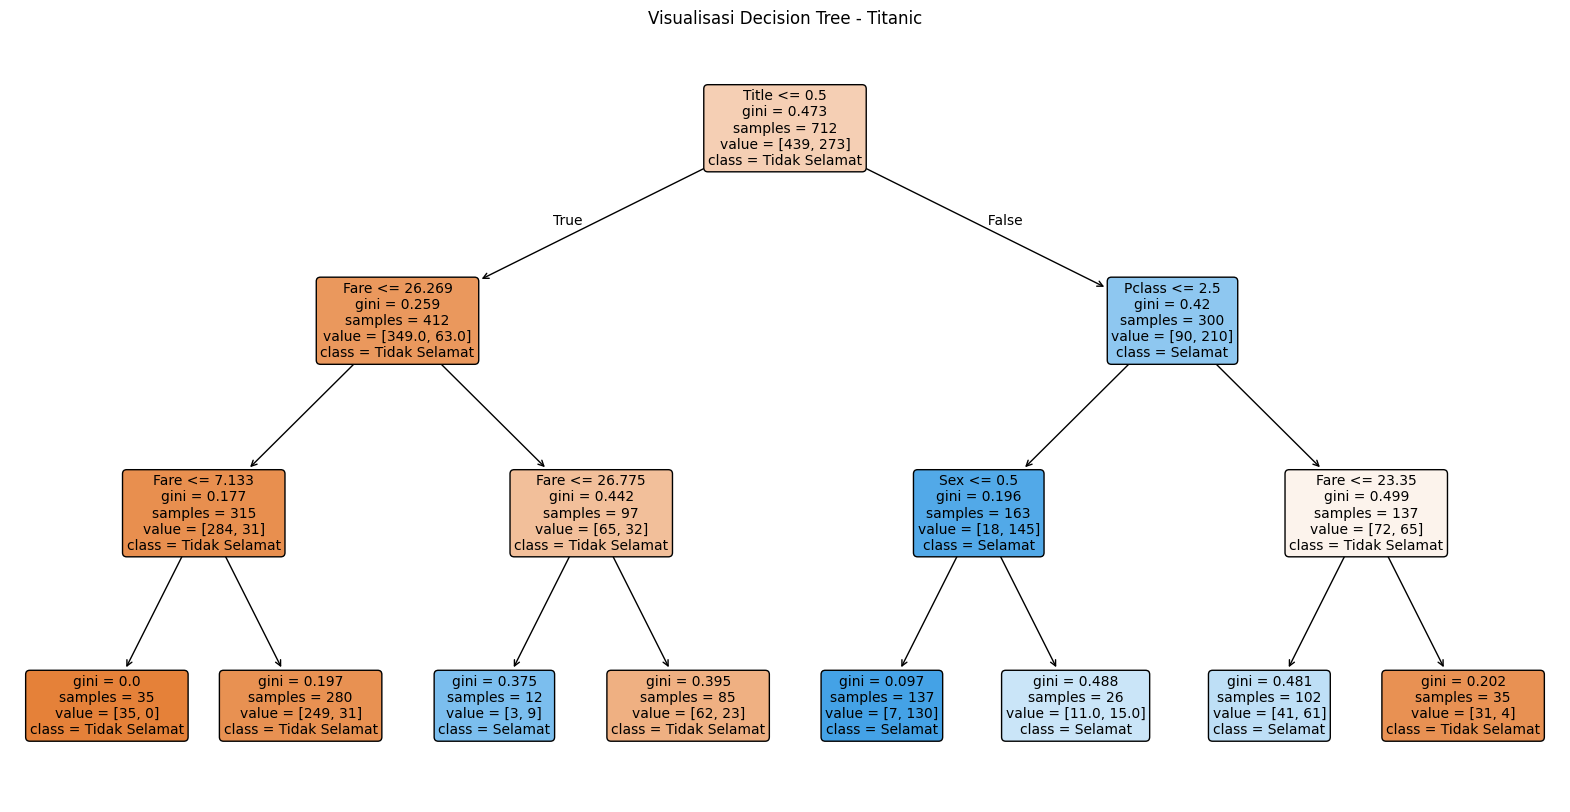

In [572]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['Tidak Selamat', 'Selamat'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualisasi Decision Tree - Titanic")
plt.show()

# Evaluasi

## Prediksi Data Uji

Model diuji menggunakan X_test_scaled (y_pred_log) dan X_test (y_pred_dt) untuk mendapatkan metrik evaluasi

In [573]:
# Prediksi menggunakan Logistic Regression (dengan data yang sudah di-scaled)
y_pred_log = log_reg.predict(X_test_scaled)

# Prediksi menggunakan Decision Tree (dengan data tanpa di-scaled)
y_pred_dt = dt.predict(X_test)

## Confusion Matrix


Logistic Regression
Accuracy  : 0.8101
Precision : 0.7869
Recall    : 0.6957
F1-Score  : 0.7385


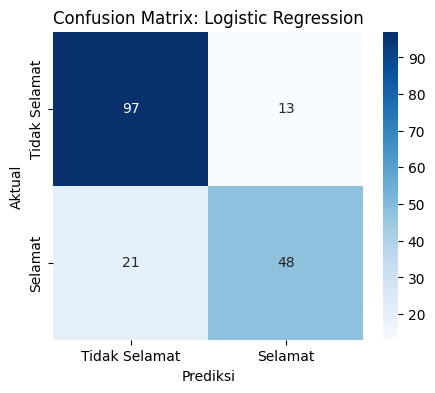


Decision Tree
Accuracy  : 0.8212
Precision : 0.7681
Recall    : 0.7681
F1-Score  : 0.7681


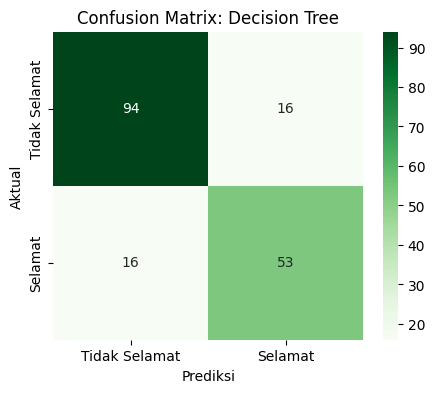

In [574]:
models = [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_dt)]

for nama, y_pred in models:
    print(f"\n{nama}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

    # Menampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if nama == 'Decision Tree' else 'Blues',
                xticklabels=['Tidak Selamat', 'Selamat'],
                yticklabels=['Tidak Selamat', 'Selamat'])
    plt.title(f'Confusion Matrix: {nama}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

In [575]:
# Classification Report untuk Logistic Regression

print("Classification Report Logistic Regression:\n",
      classification_report(y_test, y_pred_log))

# y_test adalah data asli, y_pred_log adalah hasil tebakan model
# 0 untuk Tidak Selamat
# 1 untuk Selamat

Classification Report Logistic Regression:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [576]:
# Classification Report untuk Decision Tree

print("Classification Report Decision Tree:\n",
      classification_report(y_test, y_pred_dt))

# 0 untuk Tidak Selamat
# 1 untuk Selamat

Classification Report Decision Tree:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.77      0.77      0.77        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## K-Fold Cross Validation (K=5)

In [577]:
# Setting K-Fold
# splits=5 artinya data dibagi 5 bagian untuk pengujian bergantian
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [578]:
# EVALUASI LOGISTIC REGRESSION
# Menggunakan X_train_scaled karena LogReg butuh data terstandarisasi
score_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
y_pred_log_cv = cross_val_predict(log_reg, X_train_scaled, y_train, cv=k_fold)

print(f"Rata-rata Akurasi LogReg (K-Fold): {score_log.mean():.4f}")

Rata-rata Akurasi LogReg (K-Fold): 0.8190


In [579]:
# EVALUASI DECISION TREE
# Menggunakan X_train (data asli/tidak wajib scaling)
score_dt = cross_val_score(dt, X_train, y_train, cv=k_fold, scoring='accuracy')
y_pred_dt_cv = cross_val_predict(dt, X_train, y_train, cv=k_fold)

print(f"Rata-rata Akurasi Decision Tree (K-Fold): {score_dt.mean():.4f}")

Rata-rata Akurasi Decision Tree (K-Fold): 0.8203


> Rata-Rata Akurasi K-Fold

In [580]:
# menentukan model terbaik berdasarkan rata-rata akurasi K-Fold
mean_log = score_log.mean()
mean_dt = score_dt.mean()

print(f"Score Logistic Regression: {mean_log:.4f}")
print(f"Score Decision Tree: {mean_dt:.4f}")

Score Logistic Regression: 0.8190
Score Decision Tree: 0.8203


> Standar Deviasi (Stability) K-Fold

In [581]:
score_log.std()

np.float64(0.04963960725481286)

In [582]:
score_dt.std()

np.float64(0.03972070731578332)

## Kurva ROC & AUC

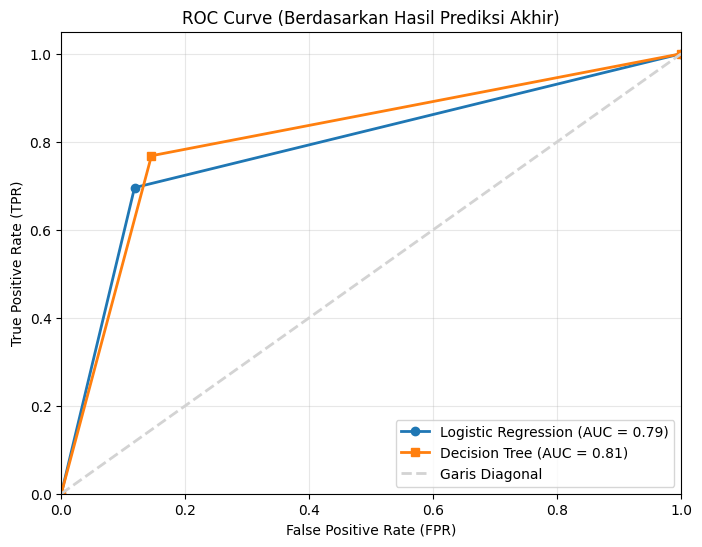

In [583]:
# ROC Curve & AUC untuk Logistic Regression menggunakan y_pred
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log)
roc_auc_log = auc(fpr_log, tpr_log)

# ROC Curve & AUC untuk Decision Tree menggunakan y_pred
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot
plt.figure(figsize=(8, 6))

# Plot LogReg
plt.plot(fpr_log, tpr_log, lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})', marker='o')

# Plot Decision Tree
plt.plot(fpr_dt, tpr_dt, lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})', marker='s')

# Garis diagonal (Random Guess)
plt.plot([0, 1], [0, 1], color='lightgrey', lw=2, linestyle='--', label="Garis Diagonal")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (Berdasarkan Hasil Prediksi Akhir)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Prediksi Data Baru (hasil_prediksi)

Karena model terbaik adalah model Decision Tree, maka prediksi untuk data_prediksi menggunakan pemodelan dt

In [584]:
pred_dt = dt.predict(data_prediksi)
pred_dt

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [585]:
data_prediksi['Prediksi_Survived'] = pred_dt

In [586]:
data_prediksi

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title,Prediksi_Survived
0,3,1,34.5,0,0,7.8292,0,1,0,0,0
1,3,0,47.0,1,0,7.0000,0,0,1,2,1
2,2,1,62.0,0,0,9.6875,0,1,0,0,0
3,3,1,27.0,0,0,8.6625,0,0,1,0,0
4,3,0,22.0,1,1,12.2875,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...
413,3,1,28.0,0,0,8.0500,0,0,1,0,0
414,1,0,39.0,0,0,108.9000,1,0,0,3,1
415,3,1,38.5,0,0,7.2500,0,0,1,0,0
416,3,1,28.0,0,0,8.0500,0,0,1,0,0


In [587]:
data_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pclass             418 non-null    int64  
 1   Sex                418 non-null    int64  
 2   Age                418 non-null    float64
 3   SibSp              418 non-null    int64  
 4   Parch              418 non-null    int64  
 5   Fare               418 non-null    float64
 6   Embarked_C         418 non-null    int64  
 7   Embarked_Q         418 non-null    int64  
 8   Embarked_S         418 non-null    int64  
 9   Title              418 non-null    int64  
 10  Prediksi_Survived  418 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 36.1 KB


> SIMPAN FILE hasil_prediksi

In [588]:
# Simpan ke file CSV
data_prediksi.to_csv('hasil_prediksi.csv', index=False)

print("File 'hasil_prediksi.csv' berhasil disimpan")

File 'hasil_prediksi.csv' berhasil disimpan


In [589]:
# Simpan ke file EXCEL
data_prediksi.to_excel('hasil_prediksi.xlsx', index=False)

print("File 'hasil_prediksi.xlsx' berhasil disimpan")# Simpan ke file CSV

File 'hasil_prediksi.xlsx' berhasil disimpan


> Hasil Prediksi (Prediksi_Survived)

Status Keselamatan Penumpang

0 => Tidak Selamat

1 => Selamat

In [590]:
data_prediksi['Prediksi_Survived'].value_counts()

,count
Prediksi_Survived,
0,246
1,172


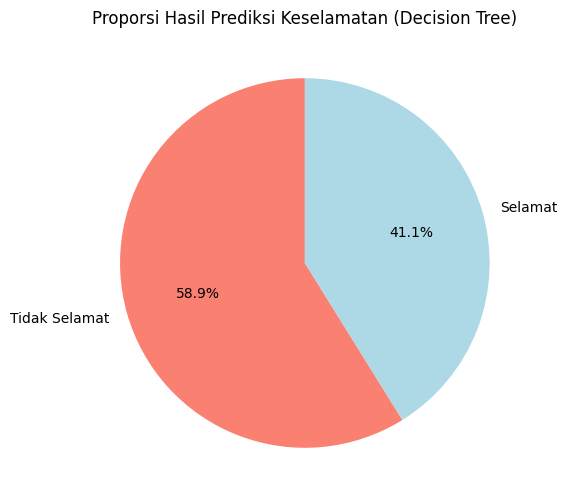

In [591]:
# definisiin
counts = data_prediksi['Prediksi_Survived'].value_counts()

# visualisasi pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=['Tidak Selamat', 'Selamat'], autopct='%1.1f%%', colors=['salmon','lightblue'], startangle=90)
plt.title('Proporsi Hasil Prediksi Keselamatan (Decision Tree)')
plt.show()

> Heatmap korelasi hasil prediksi

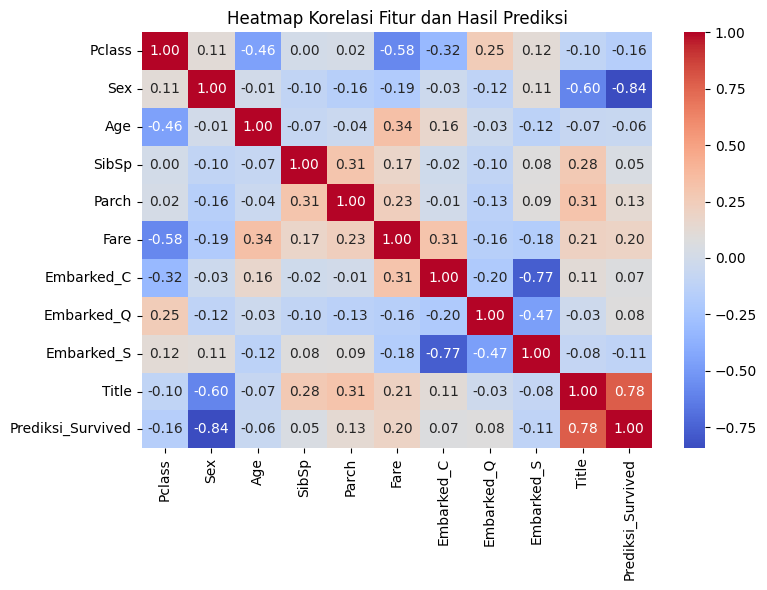

In [592]:
corr_pred = data_prediksi.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_pred,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Heatmap Korelasi Fitur dan Hasil Prediksi')
plt.tight_layout()
plt.show()

Dari heatmap di atas, korelasi tinggi/hubungan yang kuat pada variabel jenis kelamin (Sex) dan Title terhadap peluang keselamatan penumpang.

Sex => 0 = Female ; 1 = Male

Title => gelar Mr = 0, Miss = 1, Mrs = 2, dan 3 untuk gelar lainnya

Prediksi_Survived => 0 = Tidak Selamat; 1 = Selamat

Artinya, prediksi peluang penumpang perempuan masuk kategori selamat itu besar, dan prediksi peluang penumpang laki-laki masuk kategori selamat itu kecil.

Artinya, gelar Miss dan Mrs sering kali memiliki peluang selamat lebih tinggi, sementara gelar Mr lebih rendah. Gelar merepresentasikan karakteristik sosial penumpang lebih informatif.

> Menghitung jumlah per kategori (Gender vs Prediksi)

In [593]:
# Sex => 0 untuk Male (Laki-Laki) dan 1 untuk Female (Perempuan)

sex_survived = pd.crosstab(data_prediksi['Sex'],
                          data_prediksi['Prediksi_Survived'],
                          margins=True,
                          margins_name='Total')

sex_survived.columns = ['Tidak Selamat', 'Selamat', 'Total']
print(sex_survived)

       Tidak Selamat  Selamat  Total
Sex                                 
0                  6      146    152
1                240       26    266
Total            246      172    418


> Menghitung jumlah per kategori (Kelas Penumpang vs Prediksi)

In [594]:
class_survived = pd.crosstab(data_prediksi['Pclass'],
                          data_prediksi['Prediksi_Survived'],
                          margins=True,
                          margins_name='Total')

class_survived.columns = ['Tidak Selamat', 'Selamat', 'Total']
print(class_survived)

        Tidak Selamat  Selamat  Total
Pclass                               
1                  47       60    107
2                  59       34     93
3                 140       78    218
Total             246      172    418


> Bar Chart Distribusi Variabel Sex, Pclass, Title, Embarked

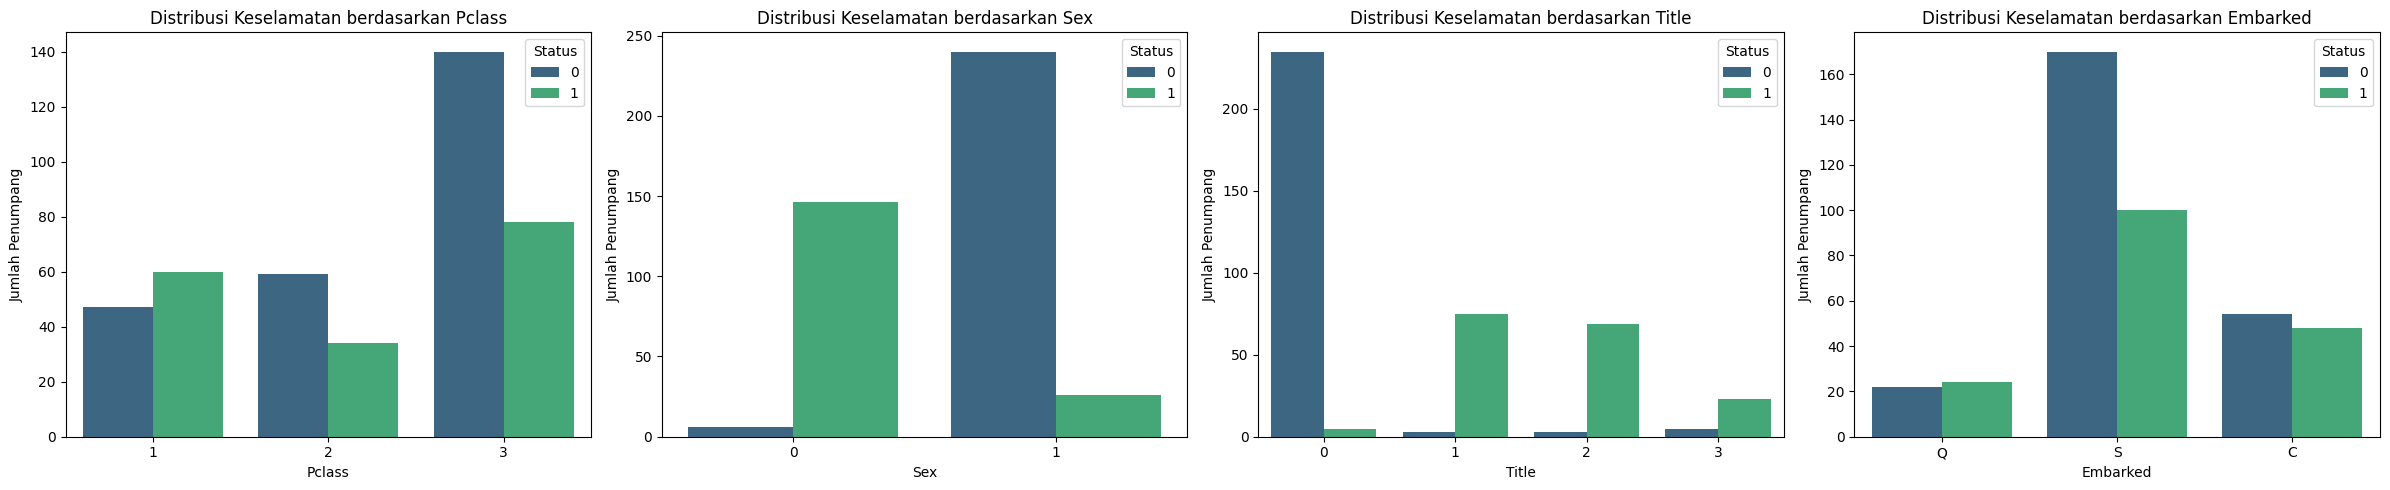

In [595]:
data_prediksi['Embarked'] = (
    data_prediksi[['Embarked_C', 'Embarked_Q', 'Embarked_S']]
    .idxmax(axis=1)
    .str.replace('Embarked_', '')
)
categorical_features = ['Pclass', 'Sex', 'Title', 'Embarked']

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, feature in enumerate(categorical_features):
    sns.countplot(
        x=feature,
        hue='Prediksi_Survived',
        data=data_prediksi,
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'Distribusi Keselamatan berdasarkan {feature}')
    axes[i].set_ylabel('Jumlah Penumpang')
    axes[i].legend(title='Status', loc='upper right')

plt.tight_layout()
plt.show()


/tmp/ipython-input-2801490816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


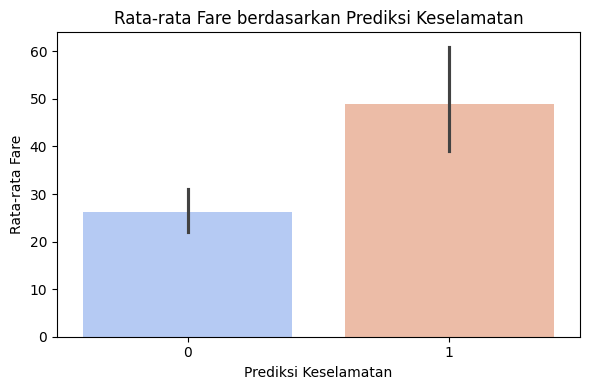

In [596]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='Prediksi_Survived',
    y='Fare',
    data=data_prediksi,
    estimator='mean',
    palette='coolwarm'
)

plt.title('Rata-rata Fare berdasarkan Prediksi Keselamatan')
plt.xlabel('Prediksi Keselamatan')
plt.ylabel('Rata-rata Fare')
plt.tight_layout()
plt.show()